In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))  # src 를 import 하기 위해

import numpy as np
import matplotlib.pyplot as plt
from src.fields.electric import PointCharge, ElectricField

print("import 성공")

import 성공


In [2]:
# +1nC 와 -1nC 를 x축 위 ±1cm 에 놓기
a = 0.01      # [m]
q = 1e-9      # [C]

field = ElectricField([
    PointCharge(+q, [-a, 0, 0]),
    PointCharge(-q, [+a, 0, 0]),
])

# xy 평면 격자 (z=0)
n = 40
x = np.linspace(-0.05, 0.05, n)
y = np.linspace(-0.05, 0.05, n)
X, Y = np.meshgrid(x, y)
R = np.stack([X, Y, np.zeros_like(X)], axis=-1)

E = field.evaluate(R)
Ex, Ey = E[..., 0], E[..., 1]

print("계산 완료. E 배열 shape:", E.shape)

계산 완료. E 배열 shape: (40, 40, 3)


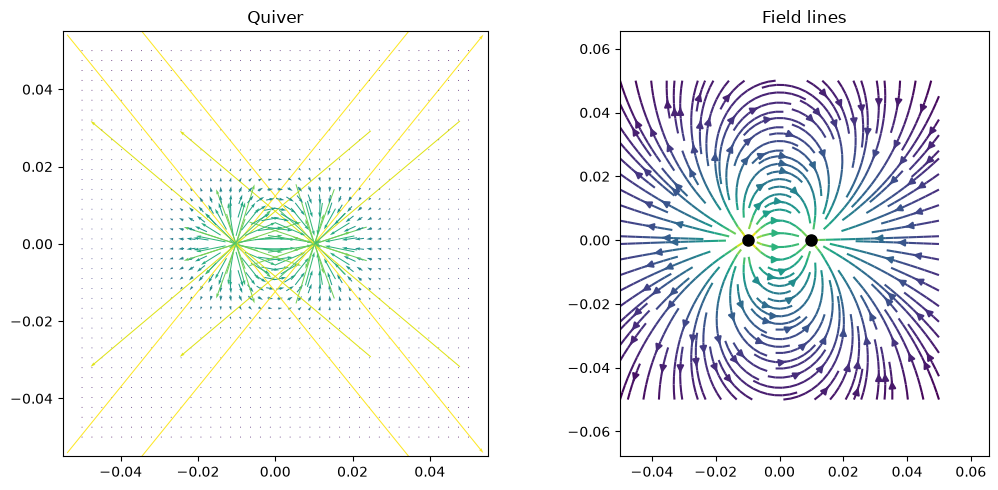

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# (a) 벡터 화살표
axes[0].quiver(X, Y, Ex, Ey, np.log(np.hypot(Ex, Ey)+1e-20), pivot="mid")
axes[0].set_title("Quiver")
axes[0].set_aspect("equal")

# (b) 전기력선
axes[1].streamplot(X, Y, Ex, Ey, density=1.4,
                   color=np.log(np.hypot(Ex, Ey)+1e-20))
axes[1].plot([-a, +a], [0, 0], "ko", ms=8)
axes[1].set_title("Field lines")
axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()